In [6]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from Bio import SeqIO
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [7]:
DATA_DIR = Path(".")

FILES = {
    "positive_truth": DATA_DIR / "RdRp-scan_0.90.fasta",
    "negative_truth": DATA_DIR / "random_selection.fasta",
    "mixed_truth_fasta": DATA_DIR / "sample_seqs_Orthornavirae.fasta",

    "PalmScan": {
        "positive": DATA_DIR / "palmscan_report_RdRp-scan_0.90",
        "negative": DATA_DIR / "palmscan_report_RdRp-scan_0.90_negatives",
        "mixed": DATA_DIR / "palmscan_report_sample_seqs_Orthornavirae",
        "format": "fasta",
    },
    "PalmAnnot": {
        "positive": DATA_DIR / "positives_hits_aa.fev",
        "negative": DATA_DIR / "negatives_hits_nt.fev",
        "mixed": DATA_DIR / "mixed_hits_nt.fev",
        "format": "fev",
        "id_column": 0,
    },
    "LucaProt": {
        "positive": DATA_DIR / "lucaprot-RdRp-scan_0.90.fasta",
        "negative": DATA_DIR / "lucaprot-random_selection.fasta",
        "mixed": DATA_DIR / "lucaprot-sample_seqs_Orthornavirae.fasta",
        "format": "fasta",
    },
}

MIXED_LABEL_FILE = DATA_DIR / "mixed_truth_labels.csv"


In [8]:
ACCESSION_PATTERN = re.compile(
    r"(?<![A-Za-z0-9])("
    r"(?:[A-Z]{1,4}_)?[A-Z]{0,3}\d{5,12}(?:\.\d+)?"
    r")(?![A-Za-z0-9])",
    flags=re.IGNORECASE,
)


def clean_text(text):
    """Remove a FASTA marker and standardise whitespace."""
    return " ".join(str(text).strip().lstrip(">").split())


def extract_accessions(text):
    """Return all accession-like identifiers found in a header or output line."""
    return {
        match.group(1).upper()
        for match in ACCESSION_PATTERN.finditer(clean_text(text))
    }


def record_signature(text):
    """
    Create the identifiers used for matching one record.

    Short first tokens are deliberately ignored because they are often
    non-unique labels such as locations or organism names.
    """
    full_header = clean_text(text)
    first_token = full_header.split()[0] if full_header else ""

    return {
        "full_header": full_header,
        "first_token": first_token if len(first_token) >= 8 else "",
        "accessions": extract_accessions(full_header),
    }


def read_truth_fasta(path, true_label=None):
    """Read every FASTA record without requiring unique headers."""
    rows = []

    for record_number, record in enumerate(
        SeqIO.parse(str(path), "fasta"),
        start=1,
    ):
        signature = record_signature(record.description)

        rows.append({
            "record_number": record_number,
            "raw_header": record.description,
            "full_header": signature["full_header"],
            "first_token": signature["first_token"],
            "accessions": signature["accessions"],
            "true_rdrp": true_label,
        })

    return pd.DataFrame(rows)


def read_prediction_records(tool_config, dataset_name):
    """
    Read tool-output identifiers.

    Supported formats:
    - fasta: FASTA output
    - fev/text: tabular or plain-text output; id_column is used for FEV
    """
    path = Path(tool_config[dataset_name])
    output_format = tool_config.get("format", "text").lower()
    records = []

    if output_format == "fasta":
        for record in SeqIO.parse(str(path), "fasta"):
            records.append(record_signature(record.description))
        return records

    id_column = tool_config.get("id_column", 0)

    with open(path, "r", encoding="utf-8", errors="ignore") as handle:
        for line in handle:
            line = line.strip()

            if not line or line.startswith("#"):
                continue

            if output_format == "fev":
                columns = line.split("\t")
                if id_column >= len(columns):
                    continue
                value = columns[id_column]
            else:
                value = line

            records.append(record_signature(value))

    return records


def is_detected(truth_row, prediction_records):
    """
    Determine whether one original FASTA record appears in the tool output.

    Matching priority:
    1. shared accession;
    2. exact complete-header match;
    3. exact sufficiently long first-token match;
    4. complete-header containment as a final fallback.
    """
    truth_accessions = truth_row["accessions"]
    truth_header = truth_row["full_header"]
    truth_token = truth_row["first_token"]

    for pred in prediction_records:
        if truth_accessions and truth_accessions.intersection(pred["accessions"]):
            return 1

        if truth_header and truth_header == pred["full_header"]:
            return 1

        if truth_token and truth_token == pred["first_token"]:
            return 1

        pred_header = pred["full_header"]
        if (
            len(truth_header) >= 15
            and len(pred_header) >= 15
            and (truth_header in pred_header or pred_header in truth_header)
        ):
            return 1

    return 0


def add_predictions(truth_df, prediction_records):
    result = truth_df.copy()
    result["predicted_rdrp"] = result.apply(
        lambda row: is_detected(row, prediction_records),
        axis=1,
    )
    return result


In [9]:
positive = read_truth_fasta(
    FILES["positive_truth"],
    true_label=1,
)

negative = read_truth_fasta(
    FILES["negative_truth"],
    true_label=0,
)

mixed = read_truth_fasta(
    FILES["mixed_truth_fasta"],
    true_label=None,
)

display(pd.DataFrame({
    "dataset": ["Positive", "Negative", "Mixed"],
    "records": [len(positive), len(negative), len(mixed)],
}))


,dataset,records
0,Positive,15081
1,Negative,15000
2,Mixed,29760


In [10]:
TOOLS = ["PalmScan", "PalmAnnot", "LucaProt"]

combined_results = {}
mixed_results = {}
summary_rows = []

for tool in TOOLS:
    positive_predictions = read_prediction_records(
        FILES[tool],
        "positive",
    )
    negative_predictions = read_prediction_records(
        FILES[tool],
        "negative",
    )
    mixed_predictions = read_prediction_records(
        FILES[tool],
        "mixed",
    )

    positive_eval = add_predictions(
        positive,
        positive_predictions,
    )
    negative_eval = add_predictions(
        negative,
        negative_predictions,
    )
    mixed_eval = add_predictions(
        mixed,
        mixed_predictions,
    )

    combined = pd.concat(
        [positive_eval, negative_eval],
        ignore_index=True,
    )

    combined_results[tool] = combined
    mixed_results[tool] = mixed_eval

    tn, fp, fn, tp = confusion_matrix(
        combined["true_rdrp"],
        combined["predicted_rdrp"],
        labels=[0, 1],
    ).ravel()

    summary_rows.append({
        "tool": tool,
        "TP": tp,
        "FN": fn,
        "FP": fp,
        "TN": tn,
        "sensitivity": tp / (tp + fn) if (tp + fn) else np.nan,
        "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
    })

summary = pd.DataFrame(summary_rows)
display(summary)


/home/kayleigh/micromamba/lib/python3.9/site-packages/Bio/SeqIO/FastaIO.py:203: BiopythonDeprecationWarning: Previously, the FASTA parser silently ignored comments at the beginning of the FASTA file (before the first sequence).

Nowadays, the FASTA file format is usually understood not to have any such comments, and most software packages do not allow them. Therefore, the use of comments at the beginning of a FASTA file is now deprecated in Biopython.

In a future Biopython release, this deprecation warning will be replaced by a ValueError. To avoid this, there are three options:

(1) Modify your FASTA file to remove such comments at the beginning of the file.

(2) Use SeqIO.parse with the 'fasta-pearson' format instead of 'fasta'. This format is consistent with the FASTA format defined by William Pearson's FASTA aligner software. Thie format allows for comments before the first sequence; lines starting with the ';' character anywhere in the file are also regarded as comment lines and 

,tool,TP,FN,FP,TN,sensitivity,specificity
0,PalmScan,12940,2141,0,15000,0.858033,1.0
1,PalmAnnot,13536,1545,0,15000,0.897553,1.0
2,LucaProt,13399,1682,0,15000,0.888469,1.0


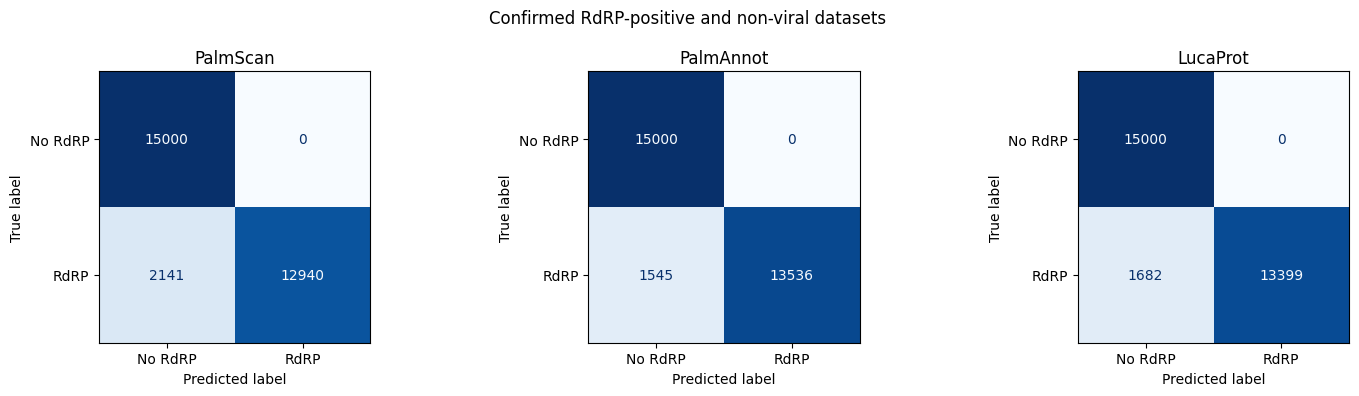

In [11]:
fig, axes = plt.subplots(
    1,
    len(TOOLS),
    figsize=(15, 4),
)

for ax, tool in zip(axes, TOOLS):
    df = combined_results[tool]

    cm = confusion_matrix(
        df["true_rdrp"],
        df["predicted_rdrp"],
        labels=[0, 1],
    )

    display_matrix = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No RdRP", "RdRP"],
    )

    display_matrix.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
    )

    ax.set_title(tool)

fig.suptitle(
    "Confirmed RdRP-positive and non-viral datasets"
)
plt.tight_layout()
plt.show()


,tool,detected,not_detected,detection_rate
0,PalmScan,14374,15386,0.482997
1,PalmAnnot,18588,11172,0.624597
2,LucaProt,19992,9768,0.671774


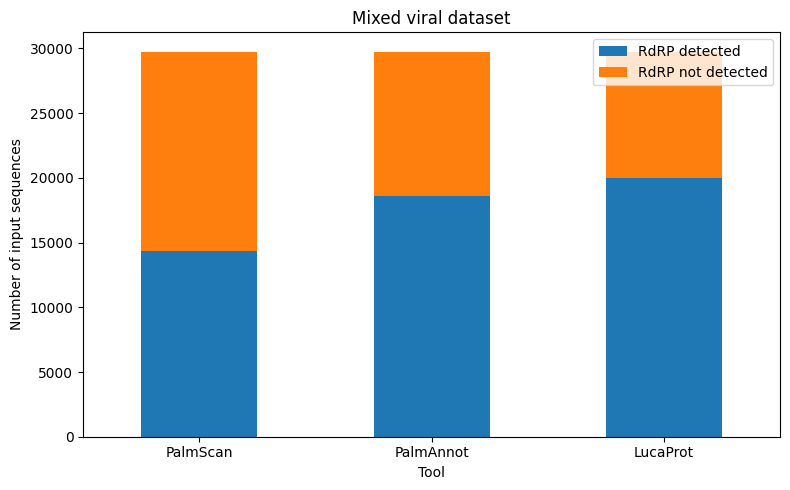

In [12]:
mixed_summary = []

for tool, df in mixed_results.items():
    detected = int(df["predicted_rdrp"].sum())
    total = len(df)

    mixed_summary.append({
        "tool": tool,
        "detected": detected,
        "not_detected": total - detected,
        "detection_rate": detected / total if total else np.nan,
    })

mixed_summary = pd.DataFrame(mixed_summary)
display(mixed_summary)

plot_data = mixed_summary.set_index("tool")[
    ["detected", "not_detected"]
]

ax = plot_data.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
)

ax.set_title("Mixed viral dataset")
ax.set_xlabel("Tool")
ax.set_ylabel("Number of input sequences")
ax.tick_params(axis="x", rotation=0)
ax.legend(["RdRP detected", "RdRP not detected"])

plt.tight_layout()
plt.show()


In [ ]:
for tool in TOOLS:
    combined = combined_results[tool]

    false_negatives = combined[
        (combined["true_rdrp"] == 1)
        & (combined["predicted_rdrp"] == 0)
    ]

    false_positives = combined[
        (combined["true_rdrp"] == 0)
        & (combined["predicted_rdrp"] == 1)
    ]

    print(
        f"{tool}: "
        f"{len(false_negatives)} false negatives, "
        f"{len(false_positives)} false positives"
    )

    display(
        false_negatives[
            ["record_number", "raw_header"]
        ].head(5)
    )

    display(
        false_positives[
            ["record_number", "raw_header"]
        ].head(5)
    )


PalmScan: 2141 false negatives, 0 false positives


,record_number,raw_header
1,2,Hainan narna-like virus 5
2,3,Sichuan narna-like virus 17
3,4,Henan sediment articulavirus
4,5,Henan orthomyxo-like virus
5,6,Yunnan orthomyxo-like virus


,record_number,raw_header


PalmAnnot: 1545 false negatives, 0 false positives


,record_number,raw_header
1,2,Hainan narna-like virus 5
2,3,Sichuan narna-like virus 17
3,4,Henan sediment articulavirus
4,5,Henan orthomyxo-like virus
5,6,Yunnan orthomyxo-like virus


,record_number,raw_header


LucaProt: 1682 false negatives, 0 false positives


,record_number,raw_header
72,73,"QCP68847.1 RNA-depedent RNA polymerase, partia..."
155,156,"APG77081.1 RNAdependent RNA polymerase, partia..."
184,185,QAY29276.1 putative RNA-dependent RNA-polymera...
188,189,"QIS87984.1 RNAdependent RNA polymerase, partia..."
266,267,"APG75979.1 hypothetical protein, partial [Wenz..."


,record_number,raw_header


In [14]:
summary.to_csv(
    "tool_confusion_matrix_summary.csv",
    index=False,
)

mixed_summary.to_csv(
    "mixed_dataset_detection_summary.csv",
    index=False,
)

print("Results exported.")


Results exported.
